Data Gathering

In [2]:
import pandas as pd
df = pd.read_csv("311_Service_Requests.csv")
df.head()

/tmp/ipykernel_338/1316942104.py:2: DtypeWarning: Columns (43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests.csv")


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
df.shape

(17844, 53)

In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17844 entries, 0 to 17843
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      17844 non-null  int64  
 1   Created Date                    17844 non-null  object 
 2   Closed Date                     17737 non-null  object 
 3   Agency                          17844 non-null  object 
 4   Agency Name                     17844 non-null  object 
 5   Complaint Type                  17844 non-null  object 
 6   Descriptor                      17559 non-null  object 
 7   Location Type                   17844 non-null  object 
 8   Incident Zip                    17721 non-null  float64
 9   Incident Address                15885 non-null  object 
 10  Street Name                     15885 non-null  object 
 11  Cross Street 1                  15618 non-null  object 
 12  Cross Street 2                  

Data Preprocessing

In [6]:
df = df[['Created Date', 'Complaint Type', 'Descriptor', 'Borough', 'Latitude', 'Longitude']]

In [7]:
df.rename(columns = {'Created Date': 'date', 'Complaint Type' : 'category', 'Descriptor' : 'complaint', 'Borough' : 'location'}, inplace=True)

In [8]:
df = df.dropna()

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.to_csv("clean_complaints.csv", index=False)

In [11]:
df.head()

,date,category,complaint,location,Latitude,Longitude
0,12/31/2015 11:59:45 PM,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,40.865682,-73.923501
1,12/31/2015 11:59:44 PM,Blocked Driveway,No Access,QUEENS,40.775945,-73.915094
2,12/31/2015 11:59:29 PM,Blocked Driveway,No Access,BRONX,40.870325,-73.888525
3,12/31/2015 11:57:46 PM,Illegal Parking,Commercial Overnight Parking,BRONX,40.835994,-73.828379
4,12/31/2015 11:56:58 PM,Illegal Parking,Blocked Sidewalk,QUEENS,40.733060,-73.874170


In [12]:
df.shape

(17401, 6)

In [13]:
df.isnull().sum()

,0
date,0
category,0
complaint,0
location,0
Latitude,0
Longitude,0


Perform EDA

In [14]:
df.head()

,date,category,complaint,location,Latitude,Longitude
0,12/31/2015 11:59:45 PM,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,40.865682,-73.923501
1,12/31/2015 11:59:44 PM,Blocked Driveway,No Access,QUEENS,40.775945,-73.915094
2,12/31/2015 11:59:29 PM,Blocked Driveway,No Access,BRONX,40.870325,-73.888525
3,12/31/2015 11:57:46 PM,Illegal Parking,Commercial Overnight Parking,BRONX,40.835994,-73.828379
4,12/31/2015 11:56:58 PM,Illegal Parking,Blocked Sidewalk,QUEENS,40.733060,-73.874170


In [15]:
df.describe()

,Latitude,Longitude
count,17401.000000,17401.000000
mean,40.719039,-73.924625
std,0.081378,0.080892
min,40.501279,-74.254937
25%,40.659506,-73.974442
50%,40.713017,-73.928998
75%,40.766396,-73.868423
max,40.910452,-73.703633


In [16]:
df['category'].value_counts()

,count
category,
Blocked Driveway,5723
Illegal Parking,5048
Noise - Commercial,2290
Noise - Street/Sidewalk,1425
Derelict Vehicle,1106
Noise - Vehicle,675
Animal Abuse,471
Vending,207
Traffic,195


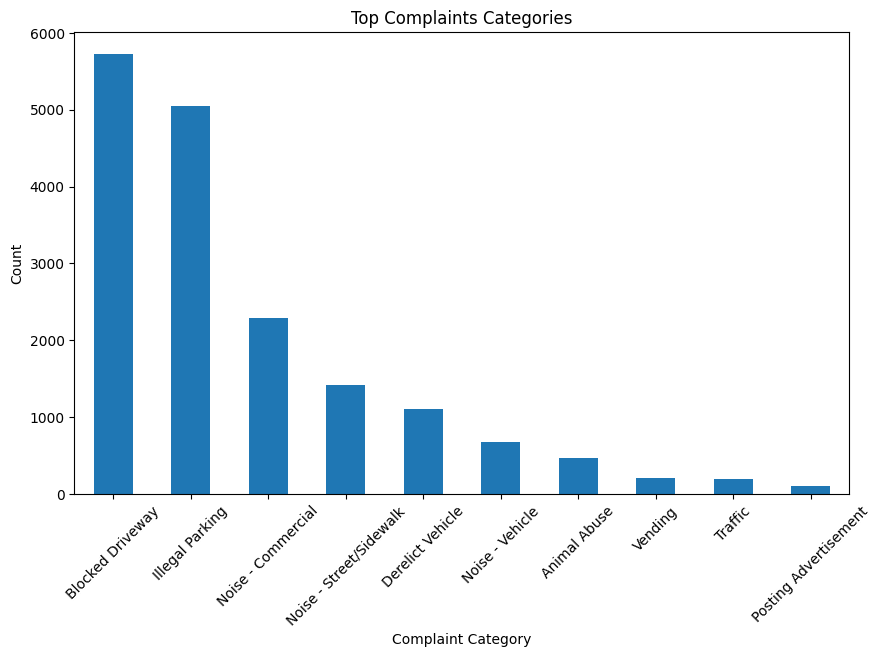

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Complaints Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

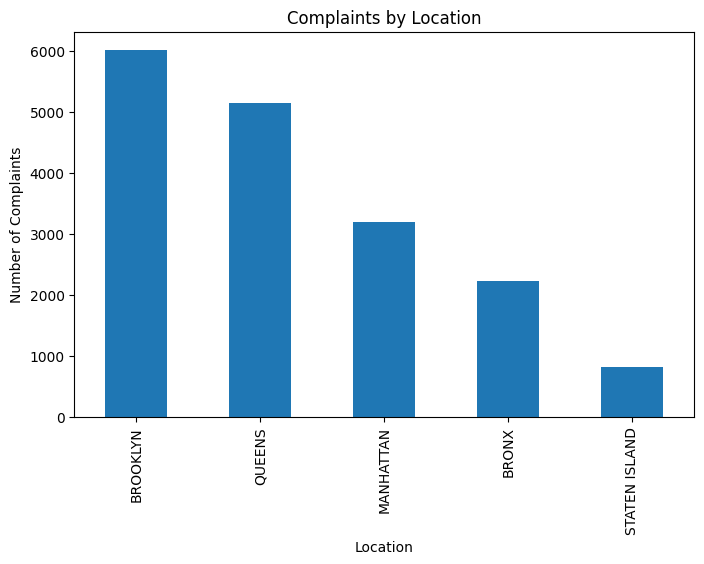

In [18]:
plt.figure(figsize=(8,5))
df['location'].value_counts().plot(kind='bar')
plt.title("Complaints by Location")
plt.xlabel("Location")
plt.ylabel("Number of Complaints")
plt.show()

In [19]:
df['complaint'].value_counts().head(10)

,count
complaint,
No Access,4300
Loud Music/Party,2582
Posted Parking Sign Violation,1481
Partial Access,1423
Blocked Hydrant,1250
With License Plate,1106
Loud Talking,889
Commercial Overnight Parking,709
Blocked Sidewalk,705


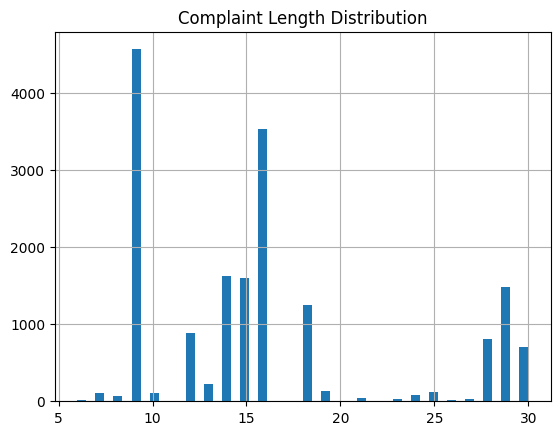

In [20]:
df['complaint_length'] = df['complaint'].apply(len)
df['complaint_length'].hist(bins=50)
plt.title("Complaint Length Distribution")
plt.show()

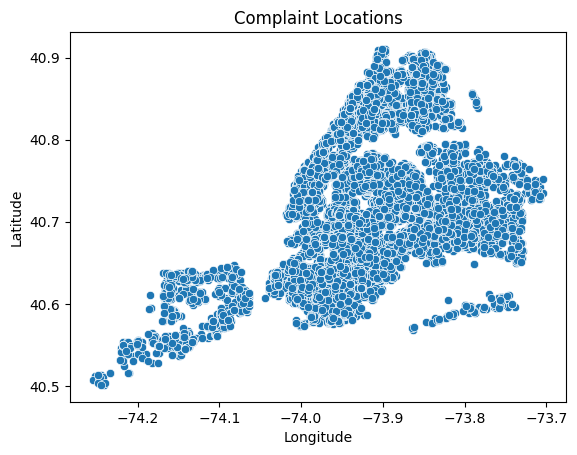

In [21]:
import seaborn as sns

sns.scatterplot(x=df['Longitude'], y=df['Latitude'])
plt.title("Complaint Locations")
plt.show()